## Multiple Linear Regression

In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, warnings as warn
from sklearn.datasets import fetch_california_housing
warn.filterwarnings('ignore')
%matplotlib inline

/home/user/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
fch = fetch_california_housing()

In [3]:
df = pd.DataFrame(fch.data, columns = fch.feature_names)

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [5]:
df['Price'] =  fch.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

In [10]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object

In [11]:
x = df.drop('Price', axis = 1)
y = df['Price']

In [12]:
x = df.drop(['AveOccup','Latitude', 'Longitude','Price'], axis = 1)
y = df['Price']

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,  x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 42)

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
std_scaler = StandardScaler()

In [17]:
x_train = std_scaler.fit_transform(x_train)

In [18]:
x_test = std_scaler.transform(x_test)

In [19]:
x_train.shape

(15480, 5)

In [20]:
x_test.shape

(5160, 5)

In [21]:
x_test

array([[-1.15411223, -0.28514924, -0.51346718, -0.17000639, -0.03105913],
       [-0.70756701,  0.11133247, -0.16361884,  0.22017837,  0.120311  ],
       [-0.20917611,  1.855852  , -0.6022714 ,  0.20282226, -0.10280682],
       ...,
       [-0.89908611,  0.66640687, -0.89340574, -0.09097557,  0.65229387],
       [ 1.58036659, -1.79177974,  0.80393479, -0.15225058,  0.81066377],
       [ 1.44652384,  0.58711053,  0.12349223, -0.09200333, -0.34517401]])

In [22]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
5363     5.00001
19755    0.63200
4885     1.17700
13043    2.63100
8583     4.81500
Name: Price, Length: 5160, dtype: float64

In [23]:
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(x_train, y_train)

LinearRegression()

In [24]:
y_pred = linear_regressor.predict(x_test)

In [25]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [26]:
linear_regressor.coef_

array([ 1.03457582,  0.20703545, -0.54216102,  0.49338344,  0.02228766])

In [27]:
r2_score(y_test, y_pred)

0.5238608930097532

In [28]:
1-(((1-r2_score(y_test,y_pred))*(len(x_test)-1))/(len(x_test)-x_test.shape[1]-1))

0.5233989807988586

In [29]:
mean_absolute_error(y_test,y_pred)

0.5758444619895525

In [30]:
mean_squared_error(y_test,y_pred)

0.630035886826658

In [31]:
np.sqrt(mean_squared_error(y_test,y_pred))

0.7937479995733268

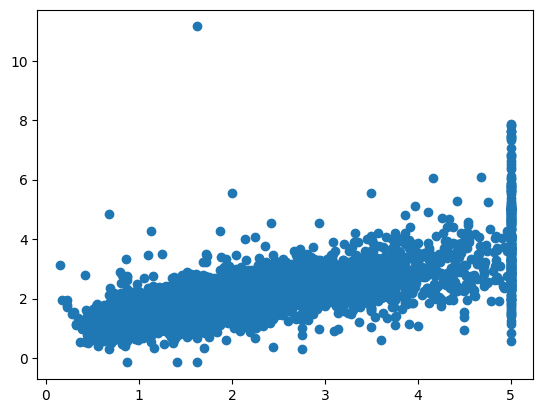

In [32]:
plt.scatter(y_test,y_pred)

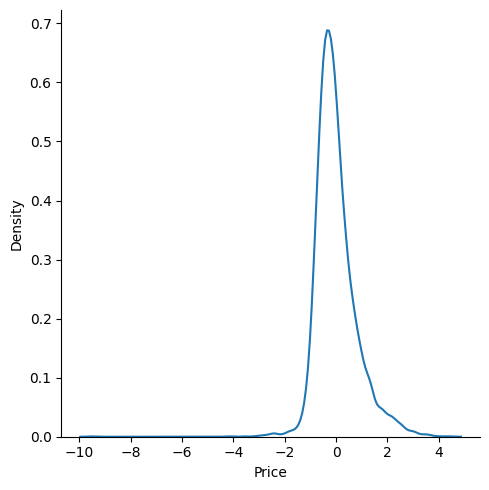

In [33]:
residuals = y_test-y_pred
sns.displot(residuals,kind="kde")

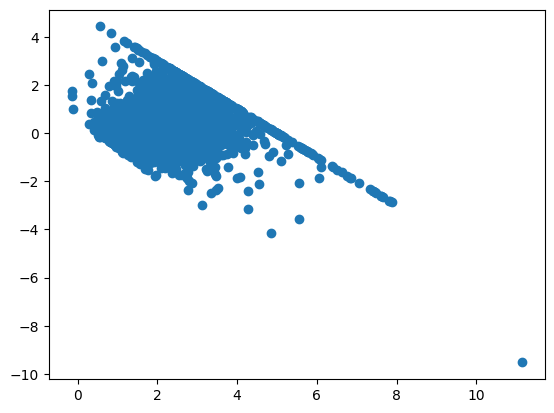

In [34]:
plt.scatter(y_pred,residuals)

In [35]:
import pickle as pkl

In [36]:
pkl.dump(linear_regressor, open('cfh.pkl', 'wb'))

In [37]:
linear_regressor = pkl.load(open('cfh.pkl','rb'))

In [38]:
r2_score(y_test, linear_regressor.predict(x_test))

0.5238608930097532

In [219]:
from sklearn.datasets import fetch_california_housing

In [220]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [221]:
california=fetch_california_housing()

In [222]:
# california

In [223]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [224]:
# print(california.DESCR)

In [225]:
california.target_names

['MedHouseVal']

In [226]:
print(california.data)

[[   8.3252       41.            6.98412698 ...    2.55555556
    37.88       -122.23      ]
 [   8.3014       21.            6.23813708 ...    2.10984183
    37.86       -122.22      ]
 [   7.2574       52.            8.28813559 ...    2.80225989
    37.85       -122.24      ]
 ...
 [   1.7          17.            5.20554273 ...    2.3256351
    39.43       -121.22      ]
 [   1.8672       18.            5.32951289 ...    2.12320917
    39.43       -121.32      ]
 [   2.3886       16.            5.25471698 ...    2.61698113
    39.37       -121.24      ]]


In [227]:
print(california.target)

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [228]:
california.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [229]:
## Lets prepare the dataframe 
dataset=pd.DataFrame(california.data,columns=california.feature_names)
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [230]:
dataset['Price']=california.target

In [231]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [232]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [233]:
dataset.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [234]:
dataset.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [235]:
dataset.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
Price,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


<Axes: >

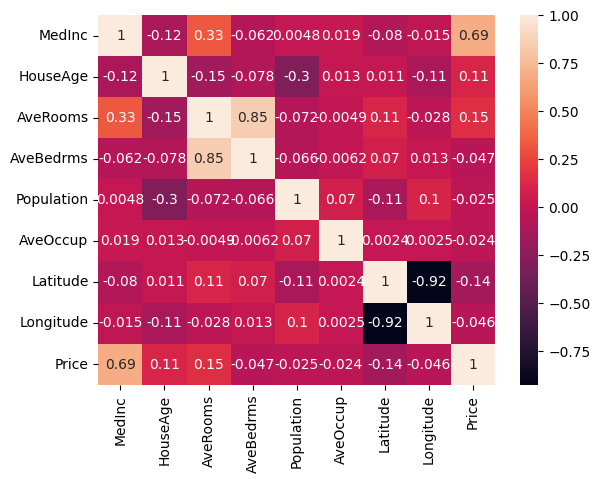

In [236]:
import seaborn as sns
sns.heatmap(dataset.corr(),annot=True)

In [237]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [238]:
## Independent and Dependent features
X=dataset.iloc[:,:-1] #independent features
y=dataset.iloc[:,-1] #dependent features

In [239]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [243]:
# x.head()

In [244]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=10)

In [245]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((13828, 8), (13828,), (6812, 8), (6812,))

In [246]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [247]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [248]:
x_train

array([[ 0.17648852,  0.66640687, -0.06085431, -0.2811182 , -0.49654414,
         0.1858249 ],
       [ 0.77137436,  1.06288858,  0.38352076, -0.02037756, -0.41167187,
         0.63079821],
       [ 0.02142423,  0.58711053,  0.27852339, -0.08462537, -0.62691494,
        -0.2080717 ],
       ...,
       [-0.49582442,  0.58711053, -0.5983225 , -0.03916402,  0.28743062,
         0.13041967],
       [ 0.96699069, -1.07811266,  0.39633361, -0.06586899,  0.30580503,
         0.66196365],
       [-0.68434939,  1.855852  , -0.83954627, -0.08684115,  1.0425313 ,
         1.02123198]])

In [249]:
X_train

array([[-0.72986836,  1.22081889, -0.70305988, ...,  0.05861244,
         0.96929441, -1.43979718],
       [-0.61046678, -0.28439808,  0.07828001, ...,  0.13015917,
        -0.75823526,  1.08204942],
       [ 0.00784578, -0.60128586, -0.2447376 , ..., -0.09793279,
         0.94594941, -1.2454256 ],
       ...,
       [ 0.88684913, -1.78961504, -0.21300658, ...,  0.09549475,
         0.78720344, -1.10587678],
       [-0.87672223,  0.50782138, -1.10043274, ...,  0.18513096,
        -0.77224225,  0.66838683],
       [-0.62742573, -0.99739558, -0.60483749, ..., -0.08418874,
         0.77786545, -1.15073176]])

In [250]:
X_test

array([[ 0.75154854, -1.31428337, -0.39376169, ...,  0.12606697,
        -0.68820027,  0.19491761],
       [ 0.05935857, -0.12595418, -0.33070668, ..., -0.12021013,
         0.89459042, -1.36503888],
       [ 0.34405687, -1.31428337, -0.41007104, ..., -0.15581759,
        -0.91698123,  0.89764561],
       ...,
       [ 0.36483158,  0.27015554,  0.04216837, ..., -0.08014641,
        -0.46875731, -0.43803598],
       [-0.90412152, -0.91817364,  0.66736933, ..., -0.10263685,
         2.51006411, -1.96808915],
       [-0.43377577,  1.22081889, -0.44835491, ...,  0.2807072 ,
        -0.74422826,  0.69330627]])

## Model Training

In [251]:
from sklearn.linear_model import LinearRegression

In [252]:
regression=LinearRegression()

In [253]:
regression

LinearRegression()

In [254]:
regression.fit(X_train,y_train)

LinearRegression()

In [255]:
## slope or coefficients
regression.coef_

array([ 0.82872299,  0.1231163 , -0.27068752,  0.32859106,  0.00213572,
       -0.02810091, -0.93017985, -0.89505497])

In [256]:
## intercepts
regression.intercept_

2.0634768086491184

In [257]:
## Prediction for the test data
y_pred=regression.predict(X_test)

In [258]:
y_test

20303    1.674
16966    3.541
10623    1.602
6146     1.408
2208     1.078
         ...  
13490    1.123
9340     3.020
17439    1.724
2602     0.838
7180     1.417
Name: Price, Length: 6812, dtype: float64

In [259]:
y_pred

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])

In [260]:
## Performance Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

0.5522332399363619
0.5371056943007959
0.7431239734636219


In [261]:
## R square and adjusted R square
scaler=StandardScaler()

from sklearn.metrics import r2_score
scaler=StandardScaler()
score=r2_score(y_test,y_pred)
print(score)

0.593595852643664


In [262]:
## Adjusted R square
#display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.5931179409607519

## Assumptions

Text(0, 0.5, 'Test Predicted Data')

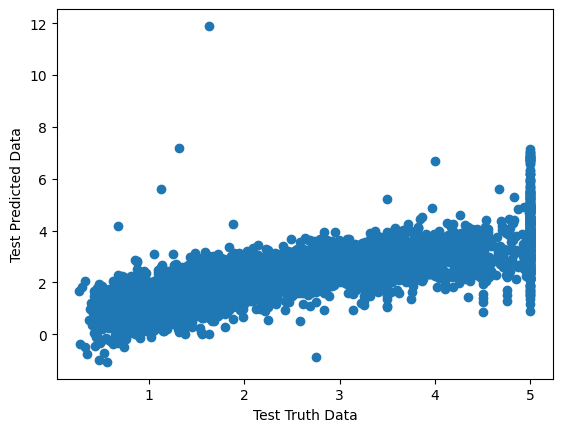

In [263]:
plt.scatter(y_test,y_pred)
plt.xlabel("Test Truth Data")
plt.ylabel("Test Predicted Data")

In [264]:
residuals=y_test-y_pred

In [44]:
residuals

20303   -1.329975
16966    0.960885
10623   -0.746908
6146    -0.307462
2208    -0.662167
           ...   
13490   -0.243475
9340     0.507182
17439   -1.366037
2602     0.046480
7180    -0.627770
Name: Price, Length: 6812, dtype: float64

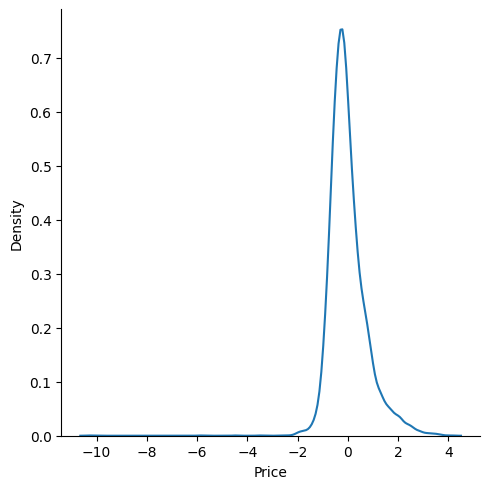

In [45]:
sns.displot(residuals,kind="kde")

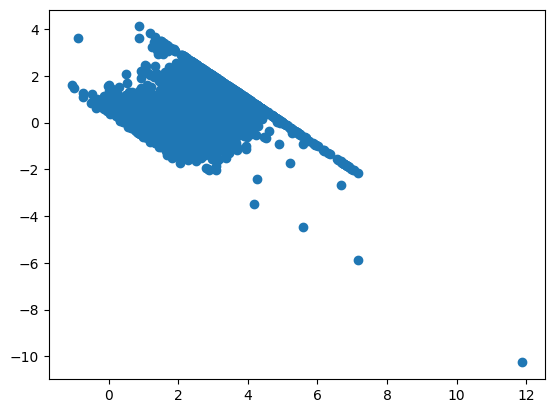

In [46]:
## SCatter plot with predictions and residual
##uniform distributionplt.scatter(y_pred,residuals)
plt.scatter(y_pred,residuals)

In [47]:
regression

LinearRegression()

## Pickling 
Python pickle module is used for serialising and de-serialising a Python object structure. Any object in Python can be pickled so that it can be saved on disk. What pickle does is that it “serialises” the object first before writing it to file. Pickling is a way to convert a python object (list, dict, etc.) into a character stream. The idea is that this character stream contains all the information necessary to reconstruct the object in another python script.

In [48]:
import pickle
pickle.dump(regression,open('regressor.pkl','wb'))plt.scatter(y_pred,residuals)

In [49]:
model=pickle.load(open('regressor.pkl','rb'))

In [50]:
model.predict(X_test)

array([3.00397485, 2.58011486, 2.3489077 , ..., 3.09003708, 0.79152007,
       2.04477012])